# 14. Bundled Worlds

TidalPy ships a set of worlds that can be built by name: rocky and icy moons, Mercury and Earth, two gas giants, the Sun, and the TRAPPIST-1 system. Each world's TOML file states a published mass and radius and describes an interior whose equation of state reproduces that mass. The comments in each file record what the interior was fitted to, where each number came from, and which observables it reproduces without being fitted to them.

This notebook builds the bundled worlds, compares their solved masses and moments of inertia with the values their files quote, solves their Love numbers, and uses them in a few tidal calculations: Jupiter's layered interior, Pluto's ocean, Io's heat budget, and the TRAPPIST-1 planets.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, au
from TidalPy.structures_x.configs import available_worlds, build_world

SECONDS_PER_DAY = 86400.0
EARTH_MASS = 5.9721986e24   # [kg]

# Every bundled world, by the name build_world accepts
bundled_names = available_worlds()
print(f"{len(bundled_names)} bundled worlds:")
print(", ".join(bundled_names))

21 bundled worlds:
charon, earth_prem, earth_simple, europa, io, jupiter, jupiter_simple, luna, mercury, neptune, pluto, sol, trappist1, trappist1b, trappist1c, trappist1d, trappist1e, trappist1f, trappist1g, trappist1h, triton


## Building a World by Name

`build_world` takes a bundled name, a path to a TOML file, or a dictionary. On first use the bundled files are copied into the user data directory, under `Worlds_x/`, and later builds read that copy, so a world can be changed by editing its file there. The builder returns the class for the world's `type`: `LayeredWorld` for a terrestrial body, `GasGiantWorld` for a gas giant, and `StarWorld` for a star.

A built world has its layers but no interior profile. `solve_eos` integrates the equation of state from the center to the surface and sets the solved mass, moment of inertia, and surface gravity.

In [2]:
# Build Io from its bundled file and list its layers
io = build_world("io")
print(f"{io.name} is a {type(io).__name__} with radius {io.radius / 1.0e3:.2f} km and mass {io.mass:.4e} kg")
for layer in io:
    print(f"    {layer.name:14} outer radius {layer.radius_outer / 1.0e3:8.2f} km, "
          f"solid: {layer.is_solid}, tidal: {layer.is_tidal}")

# Solve the interior structure
result = io.solve_eos()
print(f"EOS solve success: {result['success']}")
print(f"solved mass {io.planet_mass_eos:.4e} kg, surface gravity {io.surface_gravity_eos:.4f} m/s^2")

# The other world families
for name in ("jupiter", "sol", "trappist1"):
    world = build_world(name)
    print(f"{name:10} -> {type(world).__name__:14} {world.name}")

Io is a LayeredWorld with radius 1821.49 km and mass 8.9298e+22 kg
    core           outer radius   810.00 km, solid: True, tidal: True
    mantle         outer radius  1721.49 km, solid: True, tidal: True
    asthenosphere  outer radius  1821.49 km, solid: True, tidal: True
EOS solve success: True
solved mass 8.9298e+22 kg, surface gravity 1.7964 m/s^2
jupiter    -> GasGiantWorld  Jupiter
sol        -> StarWorld      Sol
trappist1  -> StarWorld      TRAPPIST-1


## Mass and Moment of Inertia

For each rocky and icy world the table compares the solved mass with the stated one and the solved moment-of-inertia factor $C/(M R^2)$ with the value its file quotes. The solved factor is `planet_moi_eos / (planet_mass_eos * radius**2)`, where $C$ \[kg m$^2$\] is the polar moment of inertia.

Each interior has one density fitted to the stated mass, so the mass column checks that the fit still holds. The moment-of-inertia factor measures how centrally concentrated the mass is. Only Luna's crust thickness and Earth-Simple's densities are fitted to it, so for Io, Europa, and Mercury it is an independent check on the interior. Earth-PREM takes its densities from the PREM profile, with nothing fitted. Pluto, Charon, Triton, and the TRAPPIST-1 planets have no measured moment of inertia, and their factor is a model result.

In [3]:
# Measured C/(M R^2) quoted in each world's TOML comments
measured_moi_factor = {
    "io": 0.37685,           # Anderson et al. (2001)
    "europa": 0.346,         # Anderson et al. (1998)
    "luna": 0.3931,          # Williams et al. (2014)
    "mercury": 0.346,
    "earth_simple": 0.3307,  # Williams (1994)
    "earth_prem": 0.3307,    # Williams (1994), the same Earth
}
rocky_names = ["io", "europa", "luna", "mercury", "earth_simple", "earth_prem", "pluto", "charon", "triton",
               "trappist1b", "trappist1c", "trappist1d", "trappist1e", "trappist1f", "trappist1g", "trappist1h"]

solved_worlds = {}
print(f"{'world':13} {'stated mass [kg]':>17} {'solved/stated - 1':>18} {'C/MR^2':>8} {'measured':>9} {'difference':>11}")
for name in rocky_names:
    world = build_world(name)
    world.solve_eos()
    solved_worlds[name] = world
    mass_error = world.planet_mass_eos / world.mass - 1.0
    moi_factor = world.planet_moi_eos / (world.planet_mass_eos * world.radius**2)
    if name in measured_moi_factor:
        measured = measured_moi_factor[name]
        comparison = f"{measured:9.5f} {100.0 * (moi_factor / measured - 1.0):+10.2f}%"
    else:
        comparison = f"{'-':>9} {'-':>11}"
    print(f"{name:13} {world.mass:17.5e} {mass_error:18.1e} {moi_factor:8.5f} {comparison}")

world          stated mass [kg]  solved/stated - 1   C/MR^2  measured  difference
io                  8.92980e+22            5.1e-09  0.38319   0.37685      +1.68%
europa              4.79980e+22            3.6e-09  0.34374   0.34600      -0.65%
luna                7.34579e+22           -6.1e-09  0.39312   0.39310      +0.00%
mercury             3.30103e+23           -1.8e-10  0.34646   0.34600      +0.13%
earth_simple        5.97200e+24            2.1e-07  0.33070   0.33070      -0.00%
earth_prem          5.97200e+24            5.9e-04  0.33094   0.33070      +0.07%
pluto               1.30246e+22           -9.5e-09  0.31855         -           -
charon              1.58968e+21            2.1e-08  0.31156         -           -
triton              2.14029e+22           -2.9e-08  0.31554         -           -
trappist1b          8.20580e+24            3.1e-09  0.33802         -           -
trappist1c          7.81164e+24            4.3e-10  0.33695         -           -
trappist1d      

Every fitted interior reproduces its stated mass to better than one part in a million. Earth-PREM misses by 0.06 percent, since its densities are PREM's rather than fitted to the mass. Where a factor is measured, the solved one is within 0.2 percent for Luna, Mercury, and both Earths, 0.7 percent for Europa, and 1.7 percent for Io. The Io file notes that its core radius is the parameter to adjust if that difference matters for your work.

## Love Numbers

`solve_love_numbers(frequency, degree_l=2, ...)` solves the radial problem on the solved interior at a tidal forcing frequency \[rad s$^{-1}$\], with each layer's rheology evaluated at that frequency. The results are stored on the world as the complex `love_number_k`, `love_number_h`, and `love_number_l`.

The table compares the degree-2 potential Love number $k_2$ with the published values the files quote. Luna, Mercury, and Earth-Simple each have their mantle shear modulus fitted to that value. Jupiter and Neptune are fitted only to their mass and moment-of-inertia factor, so their $k_2$ is an independent result. All of their layers are static fluids, which makes their Love number independent of frequency.

In [4]:
# (world, forcing period [days] or None for the frequency-independent fluid planets, published k2, source)
published_love = [
    ("luna", 27.3217, 0.02422, "Williams et al. (2014)"),
    ("mercury", 87.9691, 0.569, "Genova et al. (2019)"),
    ("earth_simple", 12.4206 / 24.0, 0.30, "Wahr (1981), M2 period"),
    ("jupiter", None, 0.590, "hydrostatic value quoted in jupiter.toml"),
    ("neptune", None, 0.41, "Durda (1992)"),
]

print(f"{'world':13} {'period [d]':>10} {'Re(k2)':>8} {'-Im(k2)':>9} {'published':>10} {'difference':>11}  source")
for name, period_days, published_k2, source in published_love:
    if name in solved_worlds:
        world = solved_worlds[name]
    else:
        world = build_world(name)
        world.solve_eos()
    if period_days is None:
        world.solve_love_numbers()   # Default frequency; the response of a static fluid does not depend on it
        period_label = "-"
    else:
        world.solve_love_numbers(2.0 * np.pi / (period_days * SECONDS_PER_DAY))   # Forcing frequency [rad/s]
        period_label = f"{period_days:.4f}"
    k2 = world.love_number_k
    print(f"{name:13} {period_label:>10} {k2.real:8.5f} {0.0 - k2.imag:9.2e} {published_k2:10.5f} "
          f"{100.0 * (k2.real / published_k2 - 1.0):+10.1f}%  {source}")

# Luna's tidal quality factor Q = Re(k2) / -Im(k2) at the month and the year
luna = solved_worlds["luna"]
for period_days, published_q in ((27.3217, "38 +/- 4"), (365.25, "41 +/- 9")):
    luna.solve_love_numbers(2.0 * np.pi / (period_days * SECONDS_PER_DAY))
    k2 = luna.love_number_k
    print(f"Luna Q at {period_days:8.4f} days: {k2.real / -k2.imag:5.1f}  (Williams and Boggs 2015: {published_q})")

world         period [d]   Re(k2)   -Im(k2)  published  difference  source
luna             27.3217  0.02422  6.39e-04    0.02422       +0.0%  Williams et al. (2014)
mercury          87.9691  0.56897  4.73e-03    0.56900       -0.0%  Genova et al. (2019)
earth_simple      0.5175  0.29996  1.22e-03    0.30000       -0.0%  Wahr (1981), M2 period
jupiter                -  0.53438  0.00e+00    0.59000       -9.4%  hydrostatic value quoted in jupiter.toml
neptune                -  0.42667  0.00e+00    0.41000       +4.1%  Durda (1992)
Luna Q at  27.3217 days:  37.9  (Williams and Boggs 2015: 38 +/- 4)
Luna Q at 365.2500 days:  40.9  (Williams and Boggs 2015: 41 +/- 9)


The three fitted bodies reproduce their $k_2$ to within 0.1 percent. Jupiter's solved $k_2$ is 9 percent below the value its file quotes and Neptune's is 4 percent above, with nothing tuned to either. Luna's low-viscosity zone at the base of its mantle is fitted to the two lunar $Q$ values, and both land within the published uncertainty.

Jupiter and Neptune dissipate through a fixed-$Q$ tide model, which takes $k_2$ and $Q$ from the `[tides]` table of their files rather than from the solved interior. The solved Love number is a check on the interior and does not enter their tidal heating.

## Jupiter and Jupiter-Simple

`jupiter_simple` is one uniform layer at Jupiter's mean density. It reproduces the mass but gives the uniform-sphere $C/(M R^2) = 0.4$ and the fluid-sphere $k_2 = 1.5$. `jupiter` has a dense core, a metallic hydrogen mantle, and a molecular hydrogen envelope, with the two outer densities fitted to the mass and to $C/(M R^2) = 0.264$. Concentrating the mass toward the center lowers both numbers. The density profiles come from `get_density`, which takes a float or an array of radii \[m\].

Jupiter         mass 1.8981e+27 kg, C/MR^2 = 0.2640, k2 = 0.5344
Jupiter-Simple  mass 1.8980e+27 kg, C/MR^2 = 0.4000, k2 = 1.5000
Jupiter layer masses:
    core         16.2 Earth masses
    mantle      268.4 Earth masses
    envelope     33.2 Earth masses


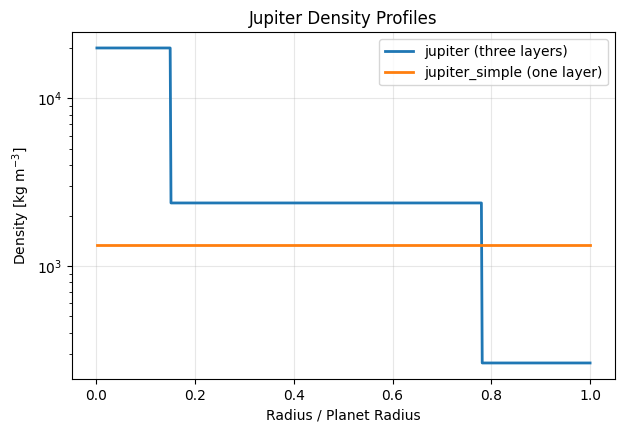

In [5]:
jupiter = build_world("jupiter")
jupiter_simple = build_world("jupiter_simple")

fig, ax = plt.subplots(figsize=(7, 4.5))
for world, label in ((jupiter, "jupiter (three layers)"), (jupiter_simple, "jupiter_simple (one layer)")):
    world.solve_eos()
    world.solve_love_numbers()   # Frequency-independent for these static fluid layers
    moi_factor = world.planet_moi_eos / (world.planet_mass_eos * world.radius**2)
    print(f"{world.name:15} mass {world.planet_mass_eos:.4e} kg, C/MR^2 = {moi_factor:.4f}, "
          f"k2 = {world.love_number_k.real:.4f}")

    radii = np.linspace(1.0e-3, 1.0, 600) * world.radius   # [m]
    ax.plot(radii / world.radius, world.get_density(radii), lw=2, label=label)

print("Jupiter layer masses:")
for layer in jupiter:
    print(f"    {layer.name:9} {layer.mass / EARTH_MASS:7.1f} Earth masses")

ax.set_yscale("log")
ax.set_xlabel("Radius / Planet Radius")
ax.set_ylabel("Density [kg m$^{-3}$]")
ax.set_title("Jupiter Density Profiles")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The layered interior puts 16 Earth masses in a 20000 kg m$^{-3}$ core within 0.15 of the radius. Its file lists the limits of a model with one density per layer: the solved central pressure is more than twice what published interior models give, so a calculation that needs a resolved pressure or density profile needs a finer interior.

## Pluto's Ocean

Pluto's file places a 165 km ice shell over a 112 km liquid water ocean on a rock core. The ocean is a static liquid layer, which decouples the shell from the core. Setting the ocean's `is_solid` flag to `True` on a second copy of Pluto freezes it into the shell, and re-solving the equation of state and the Love number shows what the ocean contributes. Both solves use the 6.387 day mutual period of Pluto and Charon, which is also Pluto's spin period.

In [6]:
pluto = solved_worlds["pluto"]
frozen_pluto = build_world("pluto")
frozen_pluto.ocean.is_solid = True   # Layers are reached by name; this makes the ocean a solid ice layer
frozen_pluto.solve_eos()

tidal_frequency = pluto.spin_frequency   # Synchronous: the mutual orbital frequency [rad/s]
love_k2 = {}
for label, world in (("with ocean", pluto), ("ocean frozen", frozen_pluto)):
    world.solve_love_numbers(tidal_frequency)
    love_k2[label] = world.love_number_k
    print(f"{label:13} k2 = {world.love_number_k.real:.6f}   h2 = {world.love_number_h.real:.4f}   "
          f"-Im(k2) = {-world.love_number_k.imag:.3e}")
print(f"The ocean raises k2 by a factor of {love_k2['with ocean'].real / love_k2['ocean frozen'].real:.1f}")

with ocean    k2 = 0.145781   h2 = 0.4731   -Im(k2) = 2.634e-02
ocean frozen  k2 = 0.004682   h2 = 0.0110   -Im(k2) = 6.093e-04
The ocean raises k2 by a factor of 31.1


With the ocean, $k_2$ is 31 times larger than for the frozen body. Pluto has no measured $k_2$, so nothing in the file is fitted to this. The shell and ocean thicknesses are also estimates: published values range from 65 to 260 km for the shell and 50 to 283 km for the ocean, and the file's comments give the sources.

## Io's Heat Budget

Io's interior has a thin, melt-weakened asthenosphere under a solid mantle. The asthenosphere viscosity is the one number fitted to a tidal observable: Io's total heat output of $(9.33 \pm 1.83) \times 10^{13}$ \[W\] from the astrometry of Lainey et al. (2009), with Jupiter's mass and Io's orbit ($a$ = 4.217e8 m, $e$ = 0.0041, synchronous rotation). The bundled worlds carry no orbital state, so the orbit is passed to `calc_tides`. Io's file sets no tide model, so the builder attaches the rheology tide model, which solves the Love number from the interior at every tidal frequency.

The tide Io raises on Jupiter dissipates in Jupiter as well, through the fixed-$Q$ model in Jupiter's file ($k_2/Q$ from Lainey et al. 2009). The same cell computes that dissipation with Io as the tidal host.

In [7]:
IO_SEMI_MAJOR_AXIS = 4.217e8   # [m]
IO_ECCENTRICITY = 0.0041
io_mean_motion = np.sqrt(G * jupiter.mass / IO_SEMI_MAJOR_AXIS**3)   # [rad/s]

io.calc_tides(
    orbital_frequency=io_mean_motion,
    spin_frequency=io_mean_motion,   # Synchronous rotation
    eccentricity=IO_ECCENTRICITY,
    obliquity=0.0,
    semi_major_axis=IO_SEMI_MAJOR_AXIS,
    host_mass=jupiter.mass)
io_heating = io.get_tidal_heating()
io_flux = io_heating / (4.0 * np.pi * io.radius**2)   # [W/m^2]
print(f"Io tidal heating      : {io_heating:.3e} W (Lainey et al. 2009: 9.33e13 +/- 1.83e13 W)")
print(f"Io surface heat flux  : {io_flux:.2f} W/m^2")
for index, layer in enumerate(io):
    layer_heating = io.get_layer_tidal_heating(index)   # This layer's share of the total [W]
    print(f"    {layer.name:14} {layer_heating:.3e} W ({100.0 * layer_heating / io_heating:.4f} percent)")

# The tide Io raises on Jupiter, with Jupiter's own spin and Io as the tidal host
jupiter.calc_tides(
    orbital_frequency=io_mean_motion,
    spin_frequency=jupiter.spin_frequency,
    eccentricity=IO_ECCENTRICITY,
    obliquity=0.0,
    semi_major_axis=IO_SEMI_MAJOR_AXIS,
    host_mass=io.mass)
print(f"Dissipation in Jupiter from Io's tide: {jupiter.get_tidal_heating():.3e} W")

Io tidal heating      : 9.330e+13 W (Lainey et al. 2009: 9.33e13 +/- 1.83e13 W)
Io surface heat flux  : 2.24 W/m^2
    core           5.971e+08 W (0.0006 percent)
    mantle         3.814e+12 W (4.0875 percent)
    asthenosphere  8.948e+13 W (95.9119 percent)
Dissipation in Jupiter from Io's tide: 3.523e+14 W


Io's heating matches the astrometric value, about 2.2 W m$^{-2}$ at the surface, and 96 percent of it is in the asthenosphere. The per-layer values are each layer's share of the radial solution's heating, which `calc_tides` resolves from the depth-resolved solution, so the layers partition the total. The dissipation in Jupiter is about four times Io's. Jupiter rotates faster than Io orbits, so most of that energy comes from Jupiter's spin, and the torque it exerts raises Io's orbit.

## TRAPPIST-1 Planets

The seven TRAPPIST-1 planets share one recipe: an incompressible iron core under a silicate mantle, with the core radius fitted to each planet's mass (Agol et al. 2021). Each is assumed to rotate synchronously, so its spin frequency is its measured orbital frequency. The cell below solves each planet's $k_2$ at its orbital period and its tidal heating with the host mass from `trappist1`, the semi-major axes of Agol et al. (2021), and the eccentricities of Grimm et al. (2018), all as quoted in the planet files.

The mantle viscosities are nominal Earth-like values, since nothing constrains them for these planets, so the heating illustrates the orbital dependence rather than predicting it. The spin and the mean motion must also agree closely. Both are taken from the measured period here. A mean motion computed from the rounded semi-major axis differs from the spin by up to 0.06 percent, and the slow tidal mode that mismatch introduces raises the heating of some planets by more than an order of magnitude.

planet       a [AU] period [d]        e  Re(k2)   -Im(k2)  heating [W]  flux [W/m^2]
TRAPPIST-1b 0.01154     1.5108  0.00216  0.4691  1.02e-03    3.502e+15     5.513e+00
TRAPPIST-1c 0.01580     2.4219  0.00028  0.4594  1.13e-03    5.698e+12     9.283e-03
TRAPPIST-1d 0.02227     4.0492  0.00381  0.2456  1.48e-03    2.012e+13     6.354e-02
TRAPPIST-1e 0.02925     6.1010  0.00447  0.3375  1.64e-03    8.580e+12     1.987e-02
TRAPPIST-1f 0.03849     9.2075  0.00445  0.4153  2.10e-03    2.642e+12     4.743e-03
TRAPPIST-1g 0.04683    12.3524  0.00254  0.4680  2.52e-03    3.489e+11     5.366e-04
TRAPPIST-1h 0.06189    18.7729  0.00184  0.2247  2.37e-03    2.829e+09     9.731e-06


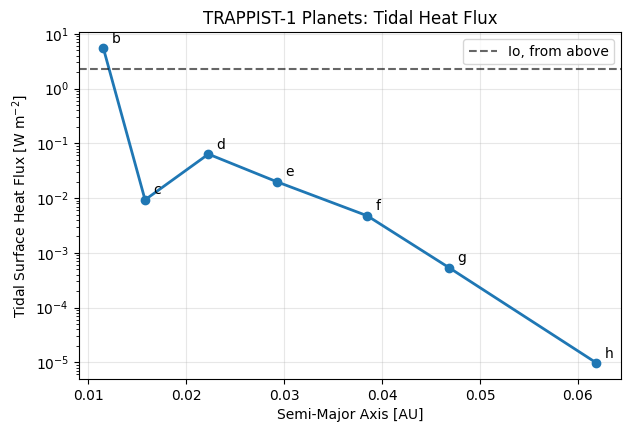

In [8]:
trappist1 = build_world("trappist1")
# Planet: (semi-major axis [AU] from Agol et al. 2021, eccentricity from Grimm et al. 2018)
trappist_orbits = {
    "trappist1b": (0.01154, 0.00216),
    "trappist1c": (0.01580, 0.00028),
    "trappist1d": (0.02227, 0.003815),
    "trappist1e": (0.02925, 0.00447),
    "trappist1f": (0.03849, 0.004455),
    "trappist1g": (0.04683, 0.00254),
    "trappist1h": (0.06189, 0.001835),
}

semi_major_axes, heat_fluxes = [], []
print(f"{'planet':11} {'a [AU]':>7} {'period [d]':>10} {'e':>8} {'Re(k2)':>7} {'-Im(k2)':>9} "
      f"{'heating [W]':>12} {'flux [W/m^2]':>13}")
for name, (semi_major_axis_au, eccentricity) in trappist_orbits.items():
    planet = solved_worlds[name]
    mean_motion = planet.spin_frequency   # Synchronous: the measured orbital frequency [rad/s]
    planet.solve_love_numbers(mean_motion)
    k2 = planet.love_number_k
    planet.calc_tides(
        orbital_frequency=mean_motion,
        spin_frequency=mean_motion,
        eccentricity=eccentricity,
        obliquity=0.0,
        semi_major_axis=semi_major_axis_au * au,
        host_mass=trappist1.mass)
    heating = planet.get_tidal_heating()
    flux = heating / (4.0 * np.pi * planet.radius**2)   # [W/m^2]
    semi_major_axes.append(semi_major_axis_au)
    heat_fluxes.append(flux)
    period_days = 2.0 * np.pi / mean_motion / SECONDS_PER_DAY
    print(f"{planet.name:11} {semi_major_axis_au:7.5f} {period_days:10.4f} {eccentricity:8.5f} {k2.real:7.4f} "
          f"{-k2.imag:9.2e} {heating:12.3e} {flux:13.3e}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(semi_major_axes, heat_fluxes, "o-", lw=2)
for semi_major_axis_au, flux, name in zip(semi_major_axes, heat_fluxes, trappist_orbits):
    ax.annotate(name[-1], (semi_major_axis_au, flux), textcoords="offset points", xytext=(6, 4))
ax.axhline(io_flux, color="k", ls="--", alpha=0.6, label="Io, from above")
ax.set_xlabel("Semi-Major Axis [AU]")
ax.set_ylabel("Tidal Surface Heat Flux [W m$^{-2}$]")
ax.set_title("TRAPPIST-1 Planets: Tidal Heat Flux")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The heat flux falls by nearly six orders of magnitude from planet b to planet h. For a fixed interior and radius the leading-order heating goes as $e^2 a^{-15/2}$, and the eccentricities differ by more than a factor of ten between planets, so the curve is not smooth: planet c has the smallest eccentricity and falls below both of its neighbors. Planet b, the innermost, has a tidal heat flux about 2.5 times Io's.